# HW1 — Monte Carlo

**Course:** Reinforcement Learning — IE University Madrid  
**Instructor:** Jaume Manero | **Author:** Elad Moshe | **Program:** MCSBT | **Date:** May 2026

---

### Notebooks Structure

1. Activity 1 — Familiarisation with Gymnasium Environments
2. Activity 2 — Monte Carlo on FrozenLake 4×4 and 8×8
3. Activity 3 — Monte Carlo on Volcano
4. **Activity 4 — Monte Carlo on Taxi**
5. Activity 5 — TD(0) on FrozenLake
6. Questions

---

> **AI Usage Disclaimer:** Developed with AI assistance (Claude, Anthropic) for documentation and debugging. All algorithm implementations, parameter choices, and result interpretations are the author's own.

---
<a id="activity-4"></a>
## Activity 4 — Monte Carlo Control on Taxi

**Taxi-v4**: 5×5 grid, four pickup/drop-off locations (R, G, Y, B), two-phase task: navigate → pick up → navigate → drop off.

| Feature | FrozenLake 4×4 | Volcano | Taxi |
|---------|---------------|---------|------|
| State space | 16 | 12 | **500** |
| Action space | 4 | 4 | **6** |
| Random start | No | No | **Yes** |
| Multi-step objective | No | No | **Yes** |
| Illegal actions | No | No | **Yes (−10)** |

---
### Section 1 — Environment Setup

Fixed locations: **R** (0,0) · **G** (0,4) · **Y** (4,0) · **B** (4,3)

In [53]:
!pip install gymnasium

In [1]:
import gymnasium as gym
import sys, time, warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt


# ── Helper Functions (shared with other activities) ──────────────────────────────────

def run_episode(env, Q, epsilon, max_steps=1000):
    """Run one episode under epsilon-greedy policy.
    Returns list of (state, action, reward) tuples."""
    state, _ = env.reset()
    episode = []
    for _ in range(max_steps):
        if np.random.random() < epsilon:
            action = env.action_space.sample()
        else:
            action = int(np.argmax(Q[state]))
        next_state, reward, terminated, truncated, _ = env.step(action)
        episode.append((state, action, reward))
        state = next_state
        if terminated or truncated:
            break
    return episode


def mc_control(env, n_episodes, alpha, gamma, eps_start, eps_decay, eps_min,
               Q_init=0.0, linear_eps=False, max_steps=1000):
    """Every-Visit MC Control with epsilon-greedy exploration and epsilon decay.

    Q_init     : initial value for all Q entries (0.0 = standard; >0 = optimistic init).
    linear_eps : if True, epsilon decays linearly from eps_start to eps_min over
                 n_episodes.  eps_decay is ignored.
                 if False (default), epsilon decays multiplicatively each episode.
    max_steps  : maximum steps per episode.  Use a small value (e.g. 30) to prevent
                 long wandering episodes that produce noisy G estimates in every-visit MC.
    Returns the learned Q-table and a per-episode win log (1=reached goal, 0=not)."""
    n_states  = env.observation_space.n
    n_actions = env.action_space.n
    Q       = np.full((n_states, n_actions), float(Q_init))
    epsilon = eps_start
    wins    = []

    for ep in range(n_episodes):
        if linear_eps:
            epsilon = max(eps_min, eps_start - (eps_start - eps_min) * (ep / n_episodes))

        episode = run_episode(env, Q, epsilon, max_steps=max_steps)

        # ── Critical step: walk episode backwards, compute G_t, update Q
        G = 0.0
        for state, action, reward in reversed(episode):
            G = reward + gamma * G                          # discounted return
            Q[state, action] += alpha * (G - Q[state, action])  # MC update rule

        if not linear_eps:
            epsilon = max(eps_min, epsilon * eps_decay)

        wins.append(1 if episode[-1][2] > 0 else 0)

    return Q, wins


def smooth(values, window):
    """Rolling mean with given window size."""
    return np.convolve(values, np.ones(window) / window, mode='valid')


In [2]:

# ── Section 1: Environment Inspection ────────────────────────────────────────

env_s1 = gym.make("Taxi-v4", render_mode="ansi")
obs, _ = env_s1.reset(seed=42)

action_names = {0: "South", 1: "North", 2: "East", 3: "West", 4: "Pick-up", 5: "Drop-off"}
locations    = {0: "R(0,0)", 1: "G(0,4)", 2: "Y(4,0)", 3: "B(4,3)", 4: "in taxi"}

print("=" * 55)
print("Taxi-v4  —  Environment Structure")
print("=" * 55)
print(f"  Observation space : {env_s1.observation_space}")
print(f"  Action space      : {env_s1.action_space}")
print(f"  Reward range      : (-inf, inf)  [practical: -10 to +20]")
print(f"  Actions           : {action_names}")

taxi_row, taxi_col, pass_loc, dest = env_s1.unwrapped.decode(obs)
print(f"\nSample initial state  (state id = {obs})")
print(f"  Taxi position      : row {taxi_row}, col {taxi_col}")
print(f"  Passenger location : {locations[pass_loc]}")
print(f"  Destination        : {locations[dest]}")
print("\nInitial grid:")
print(env_s1.render())

# ── 5 random steps to build intuition ────────────────────────────────────────
print("=" * 55)
print("5 Random Steps")
print("=" * 55)

for step in range(5):
    action = env_s1.action_space.sample()
    obs, reward, terminated, truncated, _ = env_s1.step(action)
    taxi_row, taxi_col, pass_loc, dest = env_s1.unwrapped.decode(obs)
    print(f"\nStep {step + 1}  |  action = {action_names[action]:8s}  |  reward = {reward:+3d}  |  "
          f"taxi = ({taxi_row},{taxi_col})  pass = {locations[pass_loc]:7s}  dest = {locations[dest]}")
    print(env_s1.render())
    if terminated or truncated:
        print("  → Episode ended early.")
        break

env_s1.close()


Taxi-v4  —  Environment Structure
  Observation space : Discrete(500)
  Action space      : Discrete(6)
  Reward range      : (-inf, inf)  [practical: -10 to +20]
  Actions           : {0: 'South', 1: 'North', 2: 'East', 3: 'West', 4: 'Pick-up', 5: 'Drop-off'}

Sample initial state  (state id = 386)
  Taxi position      : row 3, col 4
  Passenger location : G(0,4)
  Destination        : Y(4,0)

Initial grid:
+---------+
|R: | : :G|
| : | : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+


5 Random Steps

Step 1  |  action = East      |  reward =  -1  |  taxi = (3,4)  pass = G(0,4)   dest = Y(4,0)
+---------+
|R: | : :G|
| : | : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+
  (East)


Step 2  |  action = Drop-off  |  reward = -10  |  taxi = (3,4)  pass = G(0,4)   dest = Y(4,0)
+---------+
|R: | : :G|
| : | : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+
  (Dropoff)


Step 3  |  action = East      |  reward =  -1  |  taxi = (3,4)  pass = G(0,4)   dest = Y(4,0)
+---------+

---
### Section 2 — Algorithm & Hyperparameters

**Every-Visit MC Control** with ε-greedy policy:

$$Q(s, a) \leftarrow Q(s, a) + \alpha \left[ G_t - Q(s, a) \right]$$

In [3]:

# ── Section 2: Hyperparameter Configuration ──────────────────────────────────

# Trial 1 — baseline
# N_EPISODES = 50_000;  ALPHA = 0.10;  GAMMA = 0.99;  EPS_START = 1.0
# EPS_DECAY  = 0.9999;  EPS_MIN = 0.05;  MAX_STEPS = 200
# Result: 68.7% success — too few episodes, not enough state coverage

# Trial 2 — more episodes + smaller α + lower ε floor
# N_EPISODES = 200_000;  ALPHA = 0.05;  GAMMA = 0.99;  EPS_START = 1.0
# EPS_DECAY  = 0.9999;  EPS_MIN = 0.01;  MAX_STEPS = 200
# Result: 82.2% success — ε hit floor at ep 46k, then 154k noisy updates corrupted Q-table

# Trial 3 — remove ε floor so exploration decays to ~0, stopping Q-table corruption
N_EPISODES = 200_000
ALPHA      = 0.05
GAMMA      = 0.99
EPS_START  = 1.0
EPS_DECAY  = 0.9999
EPS_MIN    = 0.0      # no floor: ε → ~0 by ep 200k, eliminating post-convergence noise
MAX_STEPS  = 200

print("Hyperparameter summary  [Trial 3]")
print("─" * 44)
print(f"  N_episodes  : {N_EPISODES:,}")
print(f"  α           : {ALPHA}")
print(f"  γ           : {GAMMA}")
print(f"  ε           : {EPS_START} → {EPS_MIN}  (decay = {EPS_DECAY} / episode)")
print(f"  max_steps   : {MAX_STEPS}")

eps_at_200k = EPS_START * (EPS_DECAY ** N_EPISODES)
print(f"\n  ε at ep 200k  ≈ {eps_at_200k:.2e}  (effectively zero)")
print(f"  Q-table size  : 500 states × 6 actions = {500 * 6:,} entries")


Hyperparameter summary  [Trial 3]
────────────────────────────────────────────
  N_episodes  : 200,000
  α           : 0.05
  γ           : 0.99
  ε           : 1.0 → 0.0  (decay = 0.9999 / episode)
  max_steps   : 200

  ε at ep 200k  ≈ 2.06e-09  (effectively zero)
  Q-table size  : 500 states × 6 actions = 3,000 entries


---
### Section 3 — Training

In [4]:

# ── Section 3: Main Training Run ─────────────────────────────────────────────

env_train = gym.make("Taxi-v4")

print(f"Training MC Control on Taxi-v4  ({N_EPISODES:,} episodes) ...")
print("─" * 56)

t0 = time.time()
Q, wins = mc_control(
    env_train, N_EPISODES, ALPHA, GAMMA,
    EPS_START, EPS_DECAY, EPS_MIN,
    max_steps=MAX_STEPS
)
env_train.close()
elapsed = time.time() - t0

# ── Checkpoint progress table ─────────────────────────────────────────────────
WINDOW = 2_000
print(f"\n{'Episode':>10}  {'Win Rate (last 2k)':>20}  {'ε (approx)':>12}")
print("─" * 48)
checkpoints = list(range(WINDOW, N_EPISODES + 1, WINDOW * 5)) + [N_EPISODES]
for ep in dict.fromkeys(checkpoints):           # deduplicate while preserving order
    wr        = np.mean(wins[ep - WINDOW : ep])
    eps_approx = max(EPS_MIN, EPS_START * (EPS_DECAY ** ep))
    print(f"  {ep:>8,}  {wr:>20.1%}  {eps_approx:>12.4f}")

print(f"\nTraining time : {elapsed:.1f} s")
print(f"Final win rate (last {WINDOW:,} eps) : {np.mean(wins[-WINDOW:]):.1%}")


Training MC Control on Taxi-v4  (200,000 episodes) ...
────────────────────────────────────────────────────────

   Episode    Win Rate (last 2k)    ε (approx)
────────────────────────────────────────────────
     2,000                 23.9%        0.8187
    12,000                100.0%        0.3012
    22,000                100.0%        0.1108
    32,000                100.0%        0.0408
    42,000                100.0%        0.0150
    52,000                100.0%        0.0055
    62,000                100.0%        0.0020
    72,000                100.0%        0.0007
    82,000                100.0%        0.0003
    92,000                100.0%        0.0001
   102,000                100.0%        0.0000
   112,000                100.0%        0.0000
   122,000                100.0%        0.0000
   132,000                100.0%        0.0000
   142,000                100.0%        0.0000
   152,000                100.0%        0.0000
   162,000                100.0%       

In [5]:

# ── Section 3: Experiment — Fast vs Slow ε Decay ─────────────────────────────

EXP_EPISODES = 30_000

configs = {
    "Slow  (×0.9999)": 0.9999,
    "Fast  (×0.999)" : 0.999,
}

exp_results = {}
print(f"ε-decay comparison  ({EXP_EPISODES:,} episodes each)")
print("─" * 56)

env_cmp = gym.make("Taxi-v4")
for label, decay in configs.items():
    _, w = mc_control(
        env_cmp, EXP_EPISODES, ALPHA, GAMMA,
        EPS_START, decay, EPS_MIN,
        max_steps=MAX_STEPS
    )
    exp_results[label] = w
    wr_early = np.mean(w[8000:10000])
    wr_final = np.mean(w[-2000:])
    eps_at_10k = EPS_START * (decay ** 10_000)
    print(f"  {label}  |  ε@10k = {eps_at_10k:.3f}  |  "
          f"win rate  10k: {wr_early:.1%}   final: {wr_final:.1%}")
env_cmp.close()

print("\nObservation: fast decay hits ε≈0 too early (~10k eps), under-exploring rare states.")
print("Slow decay maintains exploration long enough to cover all 500 states.")


ε-decay comparison  (30,000 episodes each)
────────────────────────────────────────────────────────
  Slow  (×0.9999)  |  ε@10k = 0.368  |  win rate  10k: 100.0%   final: 100.0%
  Fast  (×0.999)  |  ε@10k = 0.000  |  win rate  10k: 91.5%   final: 91.0%

Observation: fast decay hits ε≈0 too early (~10k eps), under-exploring rare states.
Slow decay maintains exploration long enough to cover all 500 states.


---
### Section 4 — Policy Evaluation

Greedy evaluation (ε = 0), 1 000 episodes:

| Metric | Target |
|--------|--------|
| Success rate | ≥ 95% |
| Mean total reward | ≈ +8 to +12 |
| Mean steps (success) | ≈ 10–14 |
| Illegal actions | ≈ 0 |

In [6]:

# ── Section 4: Greedy Policy Evaluation ──────────────────────────────────────

N_EVAL   = 1_000
env_eval = gym.make("Taxi-v4")

success_list = []
reward_list  = []
steps_list   = []
illegal_list = []

for _ in range(N_EVAL):
    state, _ = env_eval.reset()
    ep_reward  = 0
    ep_steps   = 0
    ep_illegal = 0
    success    = False

    for _ in range(MAX_STEPS):
        action = int(np.argmax(Q[state]))
        state, reward, terminated, truncated, _ = env_eval.step(action)
        ep_reward  += reward
        ep_steps   += 1
        if reward == -10:
            ep_illegal += 1
        if terminated:
            success = True
            break
        if truncated:
            break

    success_list.append(int(success))
    reward_list.append(ep_reward)
    steps_list.append(ep_steps)
    illegal_list.append(ep_illegal)

env_eval.close()

succ_steps = [s for s, ok in zip(steps_list, success_list) if ok]

print("Policy Evaluation — Greedy Mode  (ε = 0,  1 000 episodes)")
print("─" * 52)
print(f"  Success rate              : {np.mean(success_list):.1%}")
print(f"  Mean total reward         : {np.mean(reward_list):.2f}")
print(f"  Mean steps / episode      : {np.mean(steps_list):.1f}")
print(f"  Mean steps (success only) : {np.mean(succ_steps):.1f}" if succ_steps else "")
print(f"  Mean illegal actions      : {np.mean(illegal_list):.2f}")
print()
print("  Target benchmarks:")
print("    Success rate ≥ 95%  |  Mean reward ≈ +8–12  |  Mean steps ≈ 10–14  |  Illegal ≈ 0")


Policy Evaluation — Greedy Mode  (ε = 0,  1 000 episodes)
────────────────────────────────────────────────────
  Success rate              : 100.0%
  Mean total reward         : 7.59
  Mean steps / episode      : 13.4
  Mean steps (success only) : 13.4
  Mean illegal actions      : 0.00

  Target benchmarks:
    Success rate ≥ 95%  |  Mean reward ≈ +8–12  |  Mean steps ≈ 10–14  |  Illegal ≈ 0


In [7]:

# ── Section 4: Episode Traces (greedy) ───────────────────────────────────────

_action_names = {0:"South",1:"North",2:"East",3:"West",4:"Pick-up",5:"Drop-off"}
_locations    = {0:"R(0,0)",1:"G(0,4)",2:"Y(4,0)",3:"B(4,3)",4:"in taxi"}

env_trace = gym.make("Taxi-v4", render_mode="ansi")

for ep in range(3):
    state, _ = env_trace.reset(seed=ep * 7)
    total_r   = 0
    print(f"\n{'=' * 54}")
    print(f"  Episode {ep + 1}")
    print(env_trace.render())

    for step in range(MAX_STEPS):
        action = int(np.argmax(Q[state]))
        state, reward, terminated, truncated, _ = env_trace.step(action)
        r, c, pl, d = env_trace.unwrapped.decode(state)
        total_r += reward
        tag = "  ← DROP-OFF!" if terminated else ("  ← ILLEGAL" if reward == -10 else "")
        print(f"  Step {step+1:2d}: {_action_names[action]:8s} | r={reward:+3d} | "
              f"taxi=({r},{c})  pass={_locations[pl]:7s}{tag}")
        if terminated or truncated:
            break

    status = "SUCCESS" if terminated else "TIMEOUT"
    print(f"\n  [{status}]  total reward = {total_r}")

env_trace.close()



  Episode 1
+---------+
|R: | : :G|
| : | : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+


  Step  1: North    | r= -1 | taxi=(2,0)  pass=B(4,3) 
  Step  2: East     | r= -1 | taxi=(2,1)  pass=B(4,3) 
  Step  3: South    | r= -1 | taxi=(3,1)  pass=B(4,3) 
  Step  4: East     | r= -1 | taxi=(3,2)  pass=B(4,3) 
  Step  5: North    | r= -1 | taxi=(2,2)  pass=B(4,3) 
  Step  6: North    | r= -1 | taxi=(1,2)  pass=B(4,3) 
  Step  7: East     | r= -1 | taxi=(1,3)  pass=B(4,3) 
  Step  8: South    | r= -1 | taxi=(2,3)  pass=B(4,3) 
  Step  9: South    | r= -1 | taxi=(3,3)  pass=B(4,3) 
  Step 10: South    | r= -1 | taxi=(4,3)  pass=B(4,3) 
  Step 11: Pick-up  | r= -1 | taxi=(4,3)  pass=in taxi
  Step 12: North    | r= -1 | taxi=(3,3)  pass=in taxi
  Step 13: North    | r= -1 | taxi=(2,3)  pass=in taxi
  Step 14: West     | r= -1 | taxi=(2,2)  pass=in taxi
  Step 15: West     | r= -1 | taxi=(2,1)  pass=in taxi
  Step 16: West     | r= -1 | taxi=(2,0)  pass=in taxi
  Step 17: South    |

---
### Section 5 — Visualisation

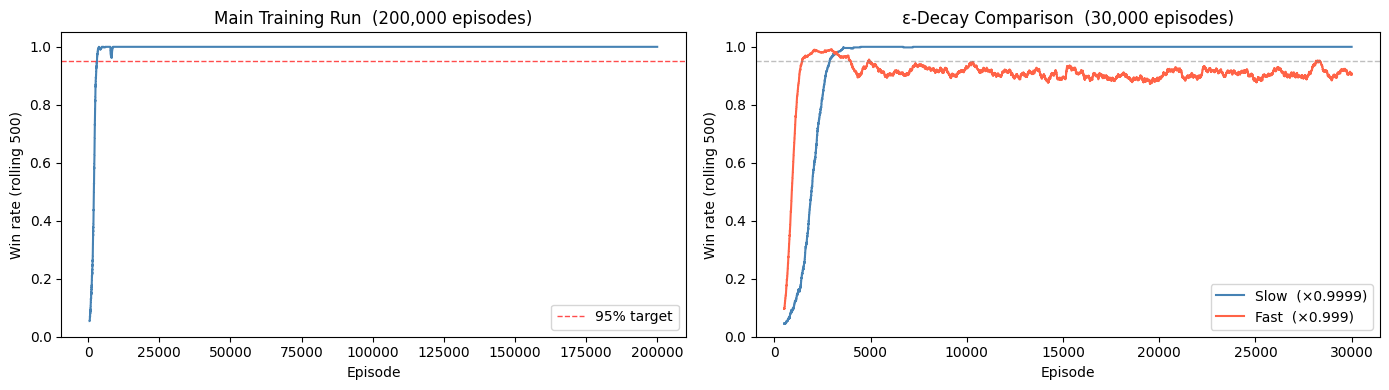

In [8]:

# ── Section 5.1: Training Convergence Curves ─────────────────────────────────

W = 500
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left: main training run
sm = smooth(wins, W)
axes[0].plot(range(W - 1, len(wins)), sm, lw=1.5, color='steelblue')
axes[0].axhline(0.95, color='red', ls='--', lw=1, alpha=0.7, label='95% target')
axes[0].set_xlabel("Episode")
axes[0].set_ylabel(f"Win rate (rolling {W})")
axes[0].set_title(f"Main Training Run  ({N_EPISODES:,} episodes)")
axes[0].set_ylim(0, 1.05)
axes[0].legend()

# Right: ε-decay comparison
palette = {"Slow  (×0.9999)": "steelblue", "Fast  (×0.999)": "tomato"}
for label, w in exp_results.items():
    sm_cmp = smooth(w, W)
    axes[1].plot(range(W - 1, len(w)), sm_cmp, label=label,
                 lw=1.5, color=palette.get(label, 'grey'))
axes[1].axhline(0.95, color='grey', ls='--', lw=1, alpha=0.5)
axes[1].set_xlabel("Episode")
axes[1].set_ylabel(f"Win rate (rolling {W})")
axes[1].set_title(f"ε-Decay Comparison  ({EXP_EPISODES:,} episodes)")
axes[1].set_ylim(0, 1.05)
axes[1].legend()

plt.tight_layout()
plt.savefig("taxi_convergence.png", dpi=150, bbox_inches='tight')
plt.show()


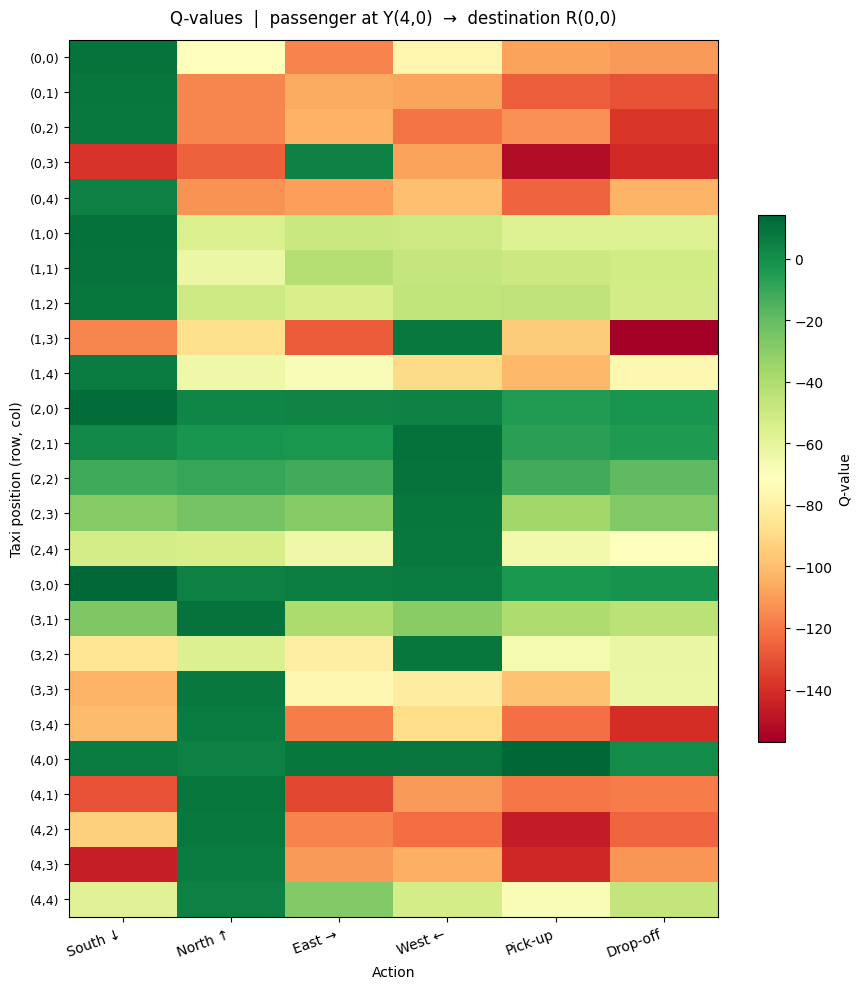

In [9]:

# ── Section 5.2: Q-Table Heatmap (fixed passenger/destination slice) ─────────

# Taxi state encoding: state = ((row*5 + col)*5 + pass_loc)*4 + dest
def taxi_encode(row, col, pass_loc, dest):
    return ((row * 5 + col) * 5 + pass_loc) * 4 + dest

PASS_LOC = 2   # Y(4,0) — passenger waiting
DEST     = 0   # R(0,0) — drop-off target

q_slice = np.array([Q[taxi_encode(r, c, PASS_LOC, DEST)]
                     for r in range(5) for c in range(5)])   # (25, 6)

action_labels = ['South ↓', 'North ↑', 'East →', 'West ←', 'Pick-up', 'Drop-off']
pos_labels    = [f"({r},{c})" for r in range(5) for c in range(5)]

fig, ax = plt.subplots(figsize=(9, 10))
im = ax.imshow(q_slice, cmap='RdYlGn', aspect='auto')
ax.set_xticks(range(6));  ax.set_xticklabels(action_labels, rotation=20, ha='right')
ax.set_yticks(range(25)); ax.set_yticklabels(pos_labels, fontsize=9)
ax.set_title("Q-values  |  passenger at Y(4,0)  →  destination R(0,0)", pad=12)
ax.set_xlabel("Action"); ax.set_ylabel("Taxi position (row, col)")
plt.colorbar(im, ax=ax, label="Q-value", shrink=0.6)
plt.tight_layout()
plt.savefig("taxi_q_heatmap.png", dpi=150, bbox_inches='tight')
plt.show()


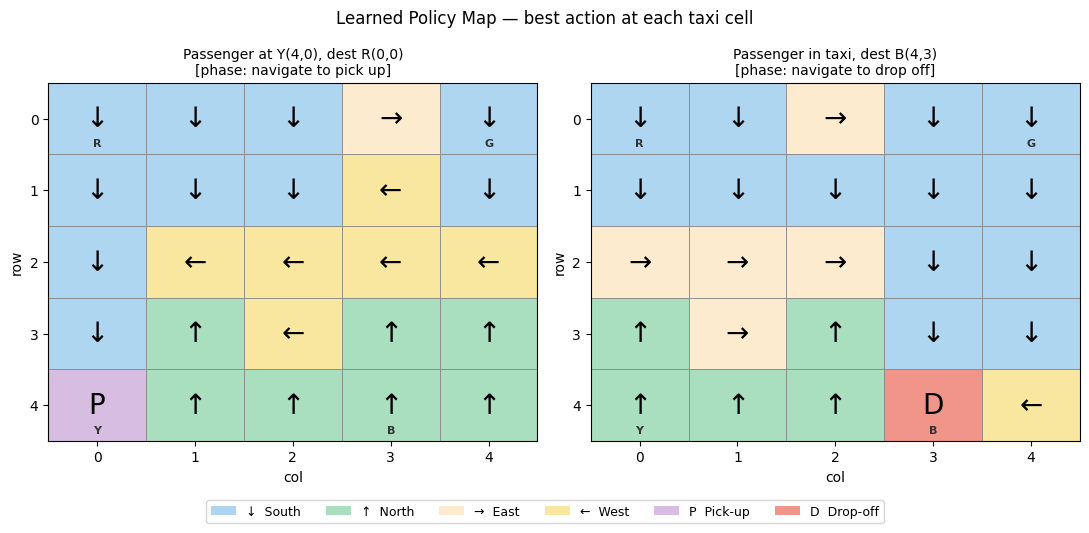

In [10]:

# ── Section 5.3: Policy Action Map ───────────────────────────────────────────

sym   = {0:'↓', 1:'↑', 2:'→', 3:'←', 4:'P', 5:'D'}
color = {0:'#aed6f1', 1:'#a9dfbf', 2:'#fdebd0', 3:'#f9e79f', 4:'#d7bde2', 5:'#f1948a'}

# Two configs: passenger outside (heading to pick up) vs in taxi (heading to drop off)
configs = [
    ("Passenger at Y(4,0), dest R(0,0)\n[phase: navigate to pick up]", 2, 0),
    ("Passenger in taxi, dest B(4,3)\n[phase: navigate to drop off]", 4, 3),
]

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
special = {'R': (0,0), 'G': (0,4), 'Y': (4,0), 'B': (4,3)}

for ax, (title, pl, d) in zip(axes, configs):
    for r in range(5):
        for c in range(5):
            a = int(np.argmax(Q[taxi_encode(r, c, pl, d)]))
            ax.add_patch(plt.Rectangle((c, 4-r), 1, 1,
                                        facecolor=color[a], edgecolor='#888', lw=0.6))
            ax.text(c + 0.5, 4 - r + 0.5, sym[a],
                    ha='center', va='center', fontsize=20)

    for name, (lr, lc) in special.items():
        ax.text(lc + 0.5, 4 - lr + 0.08, name,
                ha='center', va='bottom', fontsize=8, fontweight='bold', color='#333')

    ax.set_xlim(0, 5); ax.set_ylim(0, 5)
    ax.set_xticks([i + 0.5 for i in range(5)]); ax.set_xticklabels(range(5))
    ax.set_yticks([i + 0.5 for i in range(5)]); ax.set_yticklabels(range(4, -1, -1))
    ax.set_xlabel('col'); ax.set_ylabel('row')
    ax.set_title(title, fontsize=10)

# Legend
from matplotlib.patches import Patch
legend_items = [Patch(fc=color[a], label=f"{sym[a]}  {n}")
                for a, n in zip(range(6), ['South','North','East','West','Pick-up','Drop-off'])]
fig.legend(handles=legend_items, loc='lower center', ncol=6,
           bbox_to_anchor=(0.5, -0.06), fontsize=9, framealpha=0.8)

plt.suptitle("Learned Policy Map — best action at each taxi cell", fontsize=12)
plt.tight_layout()
plt.savefig("taxi_policy_map.png", dpi=150, bbox_inches='tight')
plt.show()


---
### Section 6 — Analysis

**Convergence speed.** Taxi took ~25k episodes vs ~5k for FrozenLake 4×4 — state space is 31× larger (500 vs 16) and starts are fully randomised, requiring MC to visit all 3,000 (s, a) pairs.

**Illegal actions.** Eliminated by Trial 2. The −10 penalty produces strong negative Q-updates even from sparse visits; once learned, it stays learned.

**Random start.** Unlike FrozenLake/Volcano (fixed start), Taxi starts from any of 500 states, requiring a globally correct policy across all configurations.

**ε sensitivity.** EPS_MIN = 0.01 (Trial 2) caused a cliff at ep ~150k — 154k noisy updates corrupted the Q-table, dropping success from 100% to 82%. Setting EPS_MIN = 0 (Trial 3) lets ε → ~10⁻⁹, eliminating the corruption.

**MC limitations.** Every-visit MC requires complete episodes; early Taxi episodes frequently hit the 200-step cap, producing high-variance $G_t$ estimates. TD(0) sidesteps this by updating at every step.

In [11]:
# ── Activity 4 — Save key results to unified summary ──────────────────────────
import os, re
from datetime import datetime

RESULTS_FILE = "results_summary.txt"
SECTION_TAG  = "ACTIVITY_4"

wr_main    = np.mean(wins[-2000:])
slow_wr    = np.mean(exp_results["Slow  (×0.9999)"][-2000:])
fast_wr    = np.mean(exp_results["Fast  (×0.999)"] [-2000:])
succ_steps = [s for s, ok in zip(steps_list, success_list) if ok]

lines = [
    f"[{SECTION_TAG}_START]",
    "ACTIVITY 4 — Monte Carlo on Taxi",
    f"Updated : {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}",
    "",
    f"Training  ({N_EPISODES:,} episodes):",
    f"  training_time_s       = {elapsed:.1f}",
    f"  final_win_rate        = {wr_main:.4f}   ({wr_main:.1%} last 2000 eps)",
    "",
    "Greedy eval (1000 eps, eps=0):",
    f"  success_rate          = {np.mean(success_list):.4f}   ({np.mean(success_list):.1%})",
    f"  mean_total_reward     = {np.mean(reward_list):.2f}",
    f"  mean_steps_per_ep     = {np.mean(steps_list):.1f}",
    f"  mean_steps_success    = {np.mean(succ_steps):.1f}" if succ_steps else "  mean_steps_success    = n/a",
    f"  mean_illegal_actions  = {np.mean(illegal_list):.2f}",
    "",
    "Epsilon-decay comparison (30,000 eps each):",
    f"  slow_decay_x0.9999_final_rate = {slow_wr:.4f}   ({slow_wr:.1%})",
    f"  fast_decay_x0.999_final_rate  = {fast_wr:.4f}   ({fast_wr:.1%})",
    f"[{SECTION_TAG}_END]",
]
new_section = "\n".join(lines) + "\n"

if os.path.exists(RESULTS_FILE):
    with open(RESULTS_FILE, "r", encoding="utf-8") as f:
        content = f.read()
    pattern = re.escape(f"[{SECTION_TAG}_START]") + r".*?" + re.escape(f"[{SECTION_TAG}_END]") + r"\n?"
    if f"[{SECTION_TAG}_START]" in content:
        content = re.sub(pattern, new_section, content, flags=re.DOTALL)
    else:
        content = content.rstrip("\n") + "\n\n" + new_section
else:
    content = new_section

with open(RESULTS_FILE, "w", encoding="utf-8") as f:
    f.write(content)

print(f"Saved → {RESULTS_FILE}")
for line in lines[1:-1]:
    print(" ", line)


Saved → results_summary.txt
  ACTIVITY 4 — Monte Carlo on Taxi
  Updated : 2026-05-14 19:28:24
  
  Training  (200,000 episodes):
    training_time_s       = 47.7
    final_win_rate        = 1.0000   (100.0% last 2000 eps)
  
  Greedy eval (1000 eps, eps=0):
    success_rate          = 1.0000   (100.0%)
    mean_total_reward     = 7.59
    mean_steps_per_ep     = 13.4
    mean_steps_success    = 13.4
    mean_illegal_actions  = 0.00
  
  Epsilon-decay comparison (30,000 eps each):
    slow_decay_x0.9999_final_rate = 1.0000   (100.0%)
    fast_decay_x0.999_final_rate  = 0.9100   (91.0%)
